# Prediciting Risk Of Smoking, Alcohol And Drug Use Among Adolscents 

### Step1- Importing libraries


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### Step2-Loading data


In [2]:
pupil = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/9366_sdd_pupil_data_archive_2023.csv", low_memory=False)
teacher = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/9366_sdd_teacher_data_archive_2023.csv", low_memory=False)
imd = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/imd.csv", low_memory=False)
lad_to_region = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/LAD19_RGN19_EN_LU.csv", low_memory=False)
print("Datasets loaded successfully:")
print(f"Pupil shape   → {pupil.shape}")
print(f"Teacher shape → {teacher.shape}")
print(f"IMD shape     → {imd.shape}")


Datasets loaded successfully:
Pupil shape   → (17466, 657)
Teacher shape → (89, 64)
IMD shape     → (32844, 57)


### Step3 - Cleaning and standardisation of pupil data


In [3]:
# Standardize column names
pupil.columns = pupil.columns.str.strip()

# Convert datayr
if "datayr" in pupil.columns:
    pupil["datayr"] = pd.to_numeric(pupil["datayr"], errors="coerce")

# ---- FIX BEHAVIOUR CODING ----
def recode_binary(series):
    series = pd.to_numeric(series, errors="coerce")
    series = series.replace(-1, np.nan)   # Missing code in SDD
    return series.apply(lambda x: 1 if x >= 2 else (0 if x == 1 else np.nan))

pupil["Smoking"] = recode_binary(pupil["lssmk"])
pupil["Alcohol"] = recode_binary(pupil["lsalc"])
pupil["Drugs"] = recode_binary(pupil["lsdrg"])

beh_cols = ["Smoking", "Alcohol", "Drugs"]

# Remove rows with missing behaviour
pupil_clean = pupil.dropna(subset=beh_cols).copy()


In [4]:
print(pupil_clean["Smoking"].value_counts(normalize=True))
print(pupil_clean["Alcohol"].value_counts(normalize=True))
print(pupil_clean["Drugs"].value_counts(normalize=True))


Smoking
0.0    0.675384
1.0    0.324616
Name: proportion, dtype: float64
Alcohol
0.0    0.657859
1.0    0.342141
Name: proportion, dtype: float64
Drugs
0.0    0.684753
1.0    0.315247
Name: proportion, dtype: float64


### Step4-Detecting and cleaning Age/gender columns


In [5]:
# --- Clean Age ---
if "age1115" in pupil_clean.columns:
    pupil_clean["age_clean"] = pd.to_numeric(pupil_clean["age1115"], errors="coerce")
    pupil_clean.loc[~pupil_clean["age_clean"].between(11, 15), "age_clean"] = np.nan

# --- Clean Gender ---
gender_map = {1: "Male", 2: "Female", 3: "Other", 4: "Other", 5: "Prefer not to say"}
if "dgender" in pupil_clean.columns:
    pupil_clean["gender_label"] = pupil_clean["dgender"].map(gender_map).fillna("Unknown")

# Keep only the final cleaned pupil columns
keep_cols = ["pseudo_pupilid", "datayr", "age_clean", "gender_label"] + beh_cols
pupil_clean = pupil_clean[keep_cols]
print("pupil_clean:", pupil_clean.shape)


pupil_clean: (14836, 7)


### Step5 --Region codes to 'region name' in pupil dataset

In [8]:
if "region" in pupil.columns:
    region_map = {
        1: "North East", 2: "North West", 3: "Yorkshire and The Humber",
        4: "East Midlands", 5: "West Midlands", 6: "East of England",
        7: "London", 8: "South East", 9: "South West"
    }
    pupil_clean["region_name"] = pupil["region"].map(region_map).fillna("Unknown")
else:
    print("Region column missing in pupil dataset")


### Step6 -- Cleaning IMD and Merging Region in Imd 

In [11]:

imd.columns = imd.columns.str.strip()
imd.rename(columns={
    "Index of Multiple Deprivation (IMD) Score": "imd_score",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile",
    "LSOA code (2011)": "lsoa_code",
    "LSOA name (2011)": "lsoa_name",
    "Local Authority District code (2019)": "lad_code",
    "Local Authority District name (2019)": "lad_name",
}, inplace=True)

imd_clean = imd.dropna(subset=["imd_score"]).copy()

#Merging Region in IMD
imd_merged = (
    imd_clean.merge(
        lad_to_region[["LAD19NM", "RGN19NM"]],
        left_on="lad_name",
        right_on="LAD19NM",
        how="left"
    )
    .rename(columns={"RGN19NM": "region"})
    .drop(columns=["LAD19NM"])
)



### Step6a ---Computing Regional_Imd

In [13]:
# LAD-level mean
lad_mean_imd = (
    imd_merged.groupby("lad_name")["imd_score"]
    .mean()
    .reset_index()
)

# Region-level mean
regional_imd = (
    lad_mean_imd.merge(imd_merged[["lad_name", "region"]].drop_duplicates(), on="lad_name")
    .groupby("region")["imd_score"]
    .mean()
    .reset_index()
    .rename(columns={"imd_score": "regional_mean_imd"})
)
print(regional_imd)

region_means = (
    pupil_clean
    .groupby("region_name")[beh_cols]
    .mean()
    .reset_index()
)

region_means = region_means.merge(
    regional_imd,
    left_on="region_name",
    right_on="region",
    how="left"
).drop(columns=["region"])



                     region  regional_mean_imd
0             East Midlands          18.402815
1           East of England          17.010682
2                    London          21.210097
3                North East          29.056214
4                North West          26.565188
5                South East          14.999831
6                South West          17.394064
7             West Midlands          20.605177
8  Yorkshire and The Humber          22.912238


#### Step6b--Aggregating imd and merging imd with pupil data

In [14]:

# Summarize IMD by region  (mean + median)

regional_stats = (
    imd_merged.groupby("region", as_index=False)
              .agg(avg_imd_score=("imd_score", "mean"),
                   median_imd_score=("imd_score", "median"))
)
print("Regional IMD summary:")
print(regional_stats)

#  Merge pupil_clean with region-level IMD
pupil_enriched = pupil_clean.merge(
    regional_stats.rename(columns={"region": "region_name"}),
    on="region_name",
    how="left",
    validate="many_to_one"   
)

# Save merged output
pupil_enriched.to_csv("pupil_with_regional_imd.csv", index=False)
print("\n Saved merged dataset: pupil_with_regional_imd.csv")

display(list(pupil_enriched.columns))


Regional IMD summary:
                     region  avg_imd_score  median_imd_score
0             East Midlands      20.360421           16.2840
1           East of England      17.348276           14.8485
2                    London      21.498424           20.3750
3                North East      28.145316           25.0400
4                North West      27.908905           23.1350
5                South East      15.477432           12.3720
6                South West      18.252656           15.5040
7             West Midlands      24.953028           20.8100
8  Yorkshire and The Humber      26.001606           20.4040

 Saved merged dataset: pupil_with_regional_imd.csv


['pseudo_pupilid',
 'datayr',
 'age_clean',
 'gender_label',
 'Smoking',
 'Alcohol',
 'Drugs',
 'region_name',
 'avg_imd_score',
 'median_imd_score']

### Step7 -- EDA 

##### 7A DEMOGRAPHIC DISTRIBUTIONS

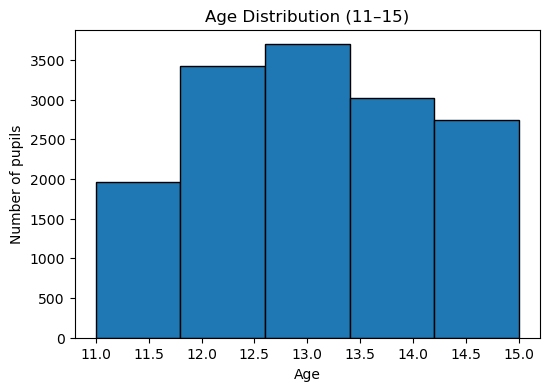

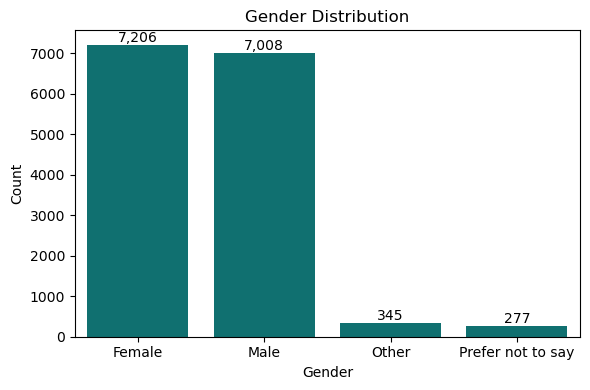

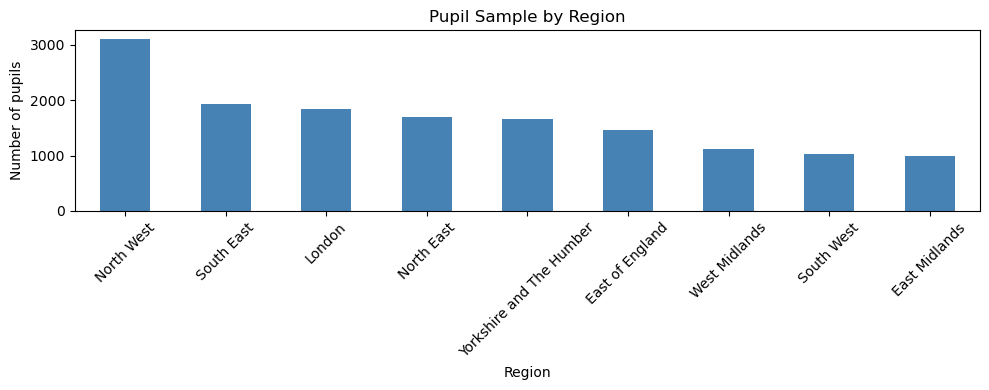

In [15]:
# --- Age ---
plt.figure(figsize=(6,4))
pupil_enriched["age_clean"].dropna().plot(kind="hist", bins=5, edgecolor="black")
plt.title("Age Distribution (11–15)")
plt.xlabel("Age")
plt.ylabel("Number of pupils")
plt.show()

#---Gender---
plt.figure(figsize=(6,4))
ax = sns.countplot(data=pupil_clean, x="gender_label", color="teal")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

# Label counts
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
# --- Region ---
plt.figure(figsize=(10,4))
pupil_clean["region_name"].value_counts().plot(kind="bar", color="steelblue", rot=45)
plt.title("Pupil Sample by Region")
plt.xlabel("Region")
plt.ylabel("Number of pupils")
plt.tight_layout()
plt.show()

# 7B BEHAVIOUR PREVALENCE


Overall behaviour prevalence (share of '1's):


Smoking    0.324616
Alcohol    0.342141
Drugs      0.315247
dtype: float64

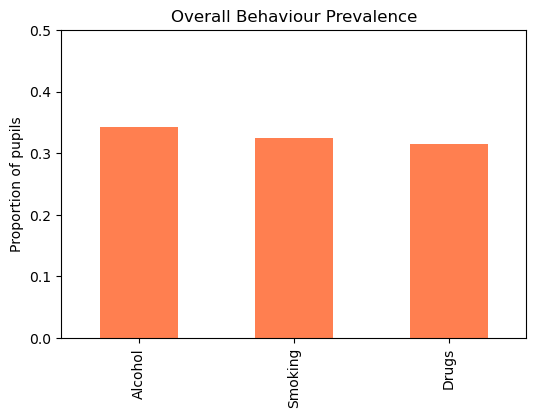


Behaviour prevalence by gender:


,Smoking,Alcohol,Drugs
gender_label,,,
Female,0.306134,0.331252,0.303358
Male,0.341467,0.351170,0.326484
Other,0.368116,0.359420,0.333333
Prefer not to say,0.324910,0.375451,0.317690


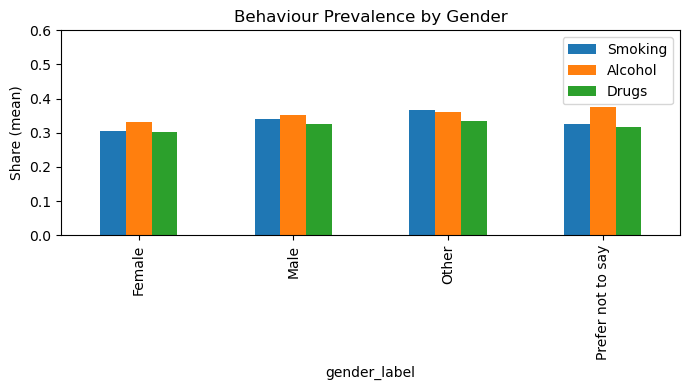

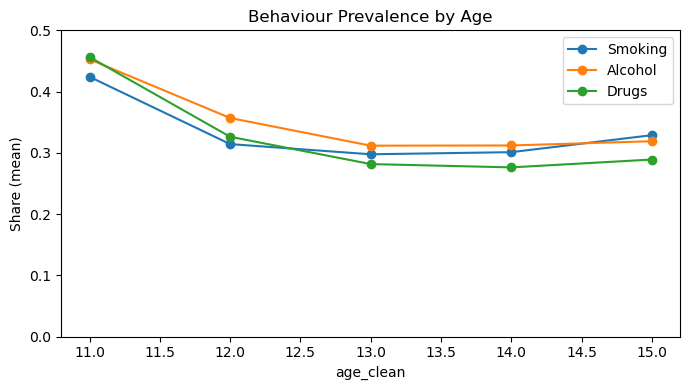

In [20]:
beh_cols = [c for c in ["Smoking", "Alcohol", "Drugs"] if c in pupil_clean.columns]

# --- Overall prevalence ---
prev_overall = pupil_clean[beh_cols].mean()
print("\nOverall behaviour prevalence (share of '1's):")
display(prev_overall)

plt.figure(figsize=(6,4))
prev_overall.sort_values(ascending=False).plot(kind="bar", color="coral")
plt.title("Overall Behaviour Prevalence")
plt.ylabel("Proportion of pupils")
plt.ylim(0,0.5)
plt.show()

# --- By gender ---
if "gender_label" in pupil_clean:
    prev_gender = pupil_clean.groupby("gender_label")[beh_cols].mean()
    print("\nBehaviour prevalence by gender:")
    display(prev_gender)

    prev_gender.plot(kind="bar", figsize=(7,4))
    plt.title("Behaviour Prevalence by Gender")
    plt.ylabel("Share (mean)")
    plt.ylim(0,0.60)
    plt.tight_layout()
    plt.show()


# --- By age ---
prev_age = pupil_clean.groupby("age_clean")[beh_cols].mean()
prev_age.plot(marker="o", figsize=(7,4))
plt.title("Behaviour Prevalence by Age")
plt.ylabel("Share (mean)")
plt.ylim(0,0.5)
plt.tight_layout()
plt.show()

##### 7C REGIONAL COMPARISONS


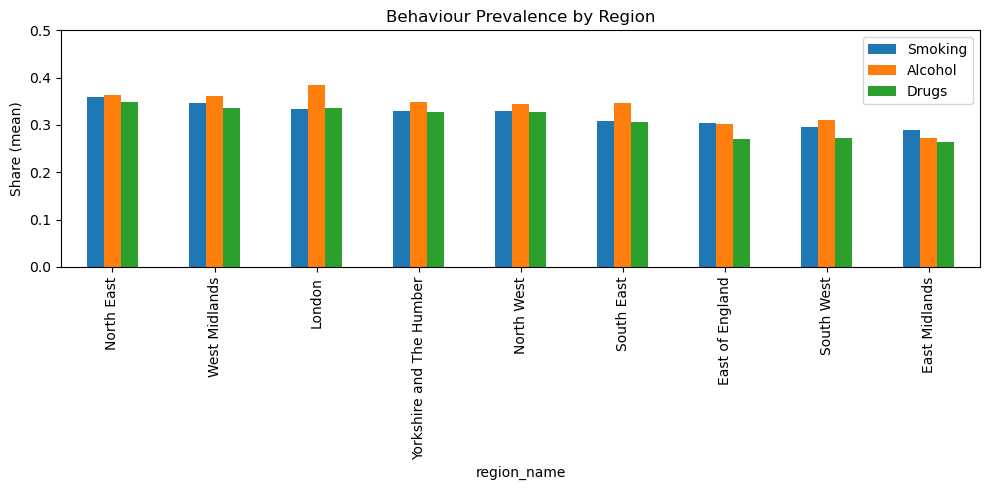

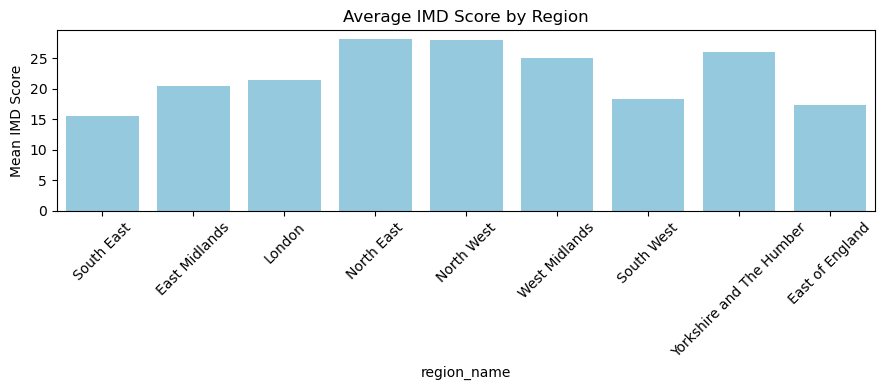

In [30]:
# --- Behaviour prevalence by region ---
prev_region = pupil_clean.groupby("region_name")[beh_cols].mean().sort_values(by="Smoking", ascending=False)
prev_region.plot(kind="bar", figsize=(10,5))
plt.title("Behaviour Prevalence by Region")
plt.ylabel("Share (mean)")
plt.ylim(0,0.5)
plt.tight_layout()
plt.show()

# --- IMD score by region ---
plt.figure(figsize=(9,4))
sns.barplot(data=pupil_enriched.drop_duplicates("region_name"),
x="region_name", y="avg_imd_score", color="skyblue")
plt.xticks(rotation=45)
plt.title("Average IMD Score by Region")
plt.ylabel("Mean IMD Score")
plt.tight_layout()
plt.show()

##### 7D REGIONAL IMD  VS BEHAVIOURS

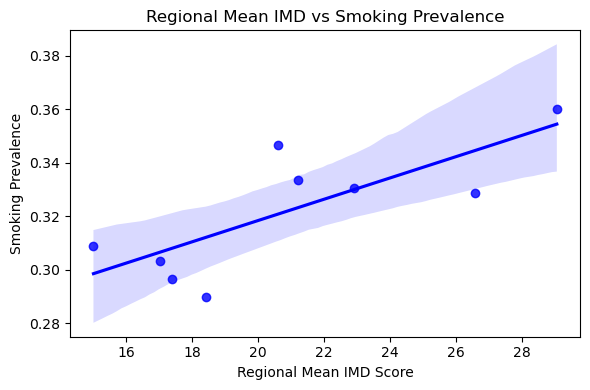

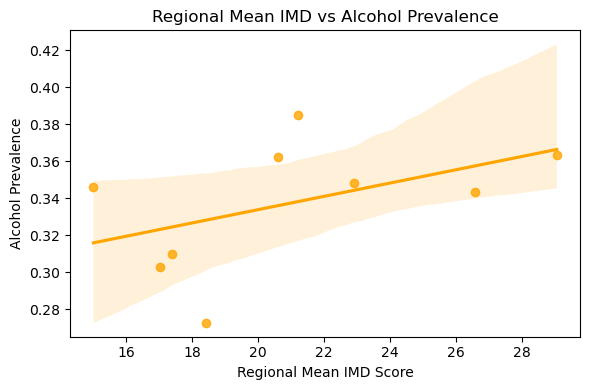

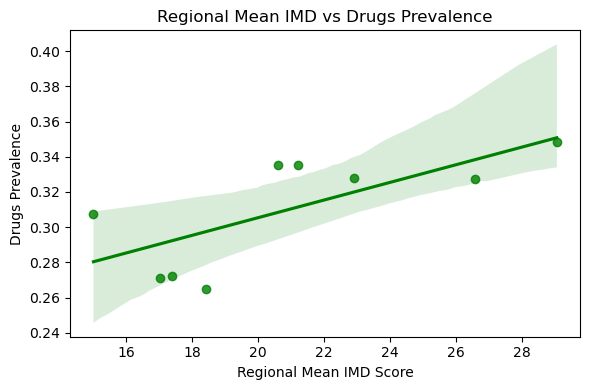

In [23]:
for col, color in zip(["Smoking", "Alcohol", "Drugs"], ["blue", "orange", "green"]):
    plt.figure(figsize=(6,4))
    sns.regplot(
        data=region_means,
        x="regional_mean_imd",
        y=col,
        marker="o",
        color=color
    )
    plt.title(f"Regional Mean IMD vs {col} Prevalence")
    plt.xlabel("Regional Mean IMD Score")
    plt.ylabel(f"{col} Prevalence")
    plt.tight_layout()
    plt.show()


##### 7E CORRELATION HEATMAP

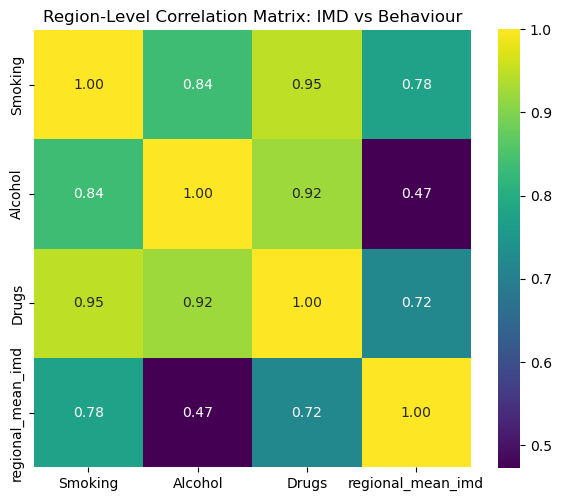

In [25]:
corr_region = region_means[["Smoking","Alcohol","Drugs","regional_mean_imd"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_region, annot=True, cmap="viridis", fmt=".2f", square=True)
plt.title("Region-Level Correlation Matrix: IMD vs Behaviour")
plt.tight_layout()
plt.show()


# Modelling

### Random Forest


 RANDOM FOREST MODEL — SMOKING

Accuracy: 0.888

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.93      0.92      2505
         1.0       0.85      0.79      0.82      1204

    accuracy                           0.89      3709
   macro avg       0.88      0.86      0.87      3709
weighted avg       0.89      0.89      0.89      3709



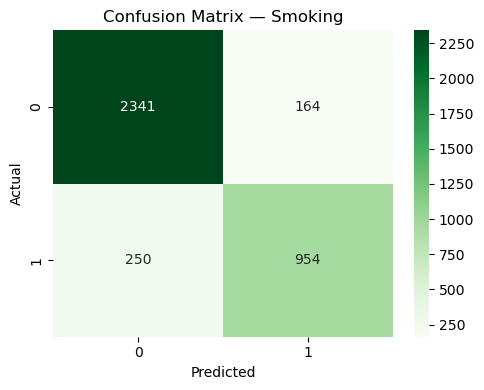


Feature Importance:
                          Feature  Importance
7                           Drugs    0.544364
6                         Alcohol    0.378049
3                       age_clean    0.035534
5             regional_median_imd    0.014209
4                regional_avg_imd    0.014099
0               gender_label_Male    0.007098
1              gender_label_Other    0.004025
2  gender_label_Prefer not to say    0.002622


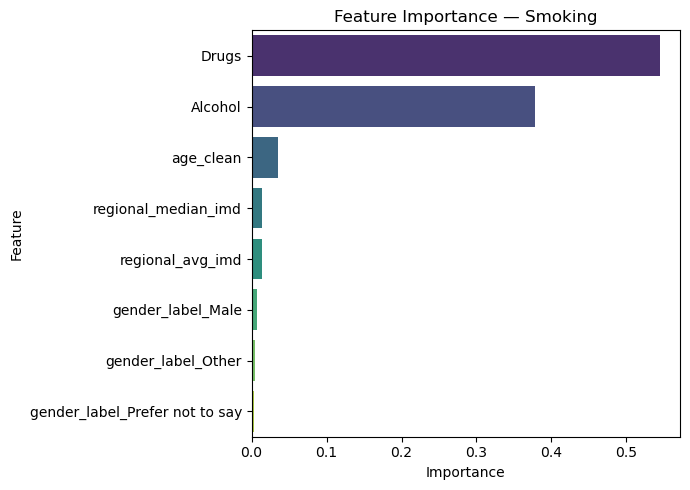


 RANDOM FOREST MODEL — ALCOHOL

Accuracy: 0.873

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.93      0.91      2440
         1.0       0.85      0.76      0.80      1269

    accuracy                           0.87      3709
   macro avg       0.87      0.85      0.85      3709
weighted avg       0.87      0.87      0.87      3709



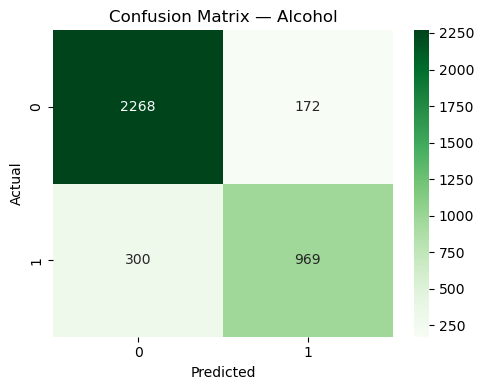


Feature Importance:
                          Feature  Importance
6                         Smoking    0.468176
7                           Drugs    0.439543
3                       age_clean    0.040984
4                regional_avg_imd    0.017650
5             regional_median_imd    0.017467
0               gender_label_Male    0.008596
1              gender_label_Other    0.004430
2  gender_label_Prefer not to say    0.003154


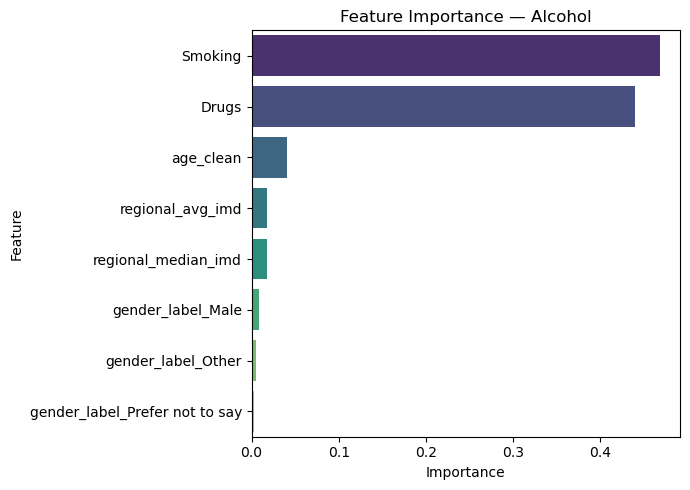


 RANDOM FOREST MODEL — DRUGS

Accuracy: 0.882

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.92      0.92      2540
         1.0       0.83      0.79      0.81      1169

    accuracy                           0.88      3709
   macro avg       0.87      0.86      0.86      3709
weighted avg       0.88      0.88      0.88      3709



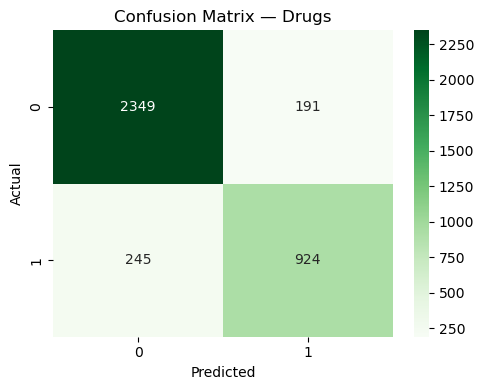


Feature Importance:
                          Feature  Importance
6                         Smoking    0.528665
7                         Alcohol    0.390941
3                       age_clean    0.038858
4                regional_avg_imd    0.013724
5             regional_median_imd    0.013705
0               gender_label_Male    0.007757
1              gender_label_Other    0.003593
2  gender_label_Prefer not to say    0.002757


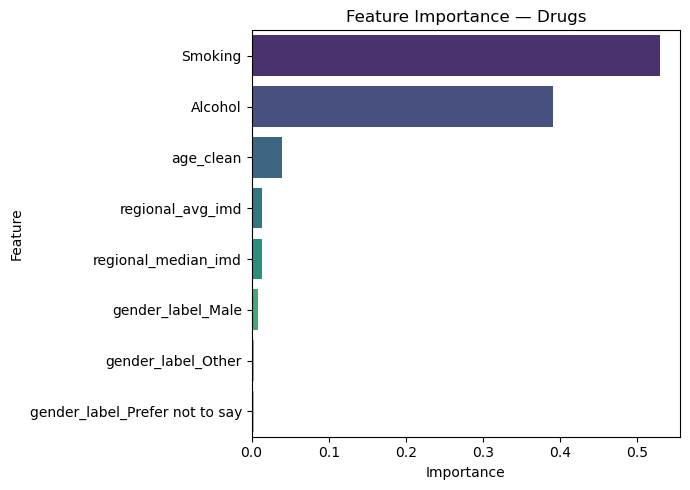

In [38]:
#Random Forest Modelling Function
def run_random_forest(target_col):
    print(f"\n==============================")
    print(f" RANDOM FOREST MODEL — {target_col.upper()}")
    print(f"==============================\n")
    
 # Dropping missing target rows
    model_data = pupil_enriched.dropna(subset=[target_col]).copy()
    
    # Predictor and Target Selection
    X = model_data[[
        "age_clean",
        "gender_label",
        "regional_avg_imd",
        "regional_median_imd",
        "Smoking",
        "Alcohol",
        "Drugs"
    ]]
    
# Removing target from predictors
    X = X.drop(columns=[target_col], errors="ignore")
    
    # Target variable
    y = model_data[target_col]
    
# Preprocessing: Encoding Gender
    preprocess = ColumnTransformer(
        transformers=[
            ("gender", OneHotEncoder(drop="first"), ["gender_label"])
        ],
        remainder="passthrough"
    )
    
# Building the Random Forest Pipeline
    rf_model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ])
    
# Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )
    
    # Train
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
# Model Evaluation
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
# Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title(f"Confusion Matrix — {target_col}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    # Extract feature names
    gender_feats = rf_model.named_steps["preprocess"].transformers_[0][1].get_feature_names_out(["gender_label"])
    
    other_feats = [
        "age_clean",
        "regional_avg_imd",
        "regional_median_imd",
        "Smoking",
        "Alcohol",
        "Drugs"
    ]
    
    other_feats = [f for f in other_feats if f != target_col]  # remove target
    
    all_features = list(gender_feats) + other_feats
    
# Feature Importance Plot
    importances = rf_model.named_steps["model"].feature_importances_
    
    importance_df = pd.DataFrame({
        "Feature": all_features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    print("\nFeature Importance:")
    print(importance_df)
    
    plt.figure(figsize=(7, 5))
    sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Feature Importance — {target_col}")
    plt.tight_layout()
    plt.show()
    
    return importance_df


#Running Models for All Behaviours

rf_smoking = run_random_forest("Smoking")
rf_alcohol = run_random_forest("Alcohol")
rf_drugs = run_random_forest("Drugs")
